In [ ]:
import pandas as pd

# 1. Load the datasets
sales_df = pd.read_csv('sales_data.csv')
customer_df = pd.read_csv('customer_churn.csv')

# 2. Check for missing values
print("Missing values in Sales Data:\n", sales_df.isnull().sum())
print("\nMissing values in Customer Data:\n", customer_df.isnull().sum())

Missing values in Sales Data:
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Missing values in Customer Data:
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [ ]:
# 1. Handle Datetime Data

sales_df['Date'] = pd.to_datetime(sales_df['Date'])

sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Day'] = sales_df['Date'].dt.day

# 2. Clean and Transform Text Data (String Methods)

sales_df['Merge_ID'] = sales_df['Customer_ID'].str.replace('CUST', '').astype(int)
customer_df['Merge_ID'] = customer_df['CustomerID'].str.replace('C', '').astype(int)

# 3. Create Calculated Columns

sales_df['Calculated_Total'] = sales_df['Quantity'] * sales_df['Price']

print("Data Cleaning Complete. Sample of prepared Sales Data:")
display(sales_df.head())

Data Cleaning Complete. Sample of prepared Sales Data:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day,Merge_ID,Calculated_Total
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,1,1,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,2,2,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,3,3,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,4,4,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,5,5,318680


In [ ]:
# Day 3: Customer Analysis

# 1. Merge datasets using the 'Merge_ID' we created on Day 2

merged_df = pd.merge(sales_df, customer_df, on='Merge_ID', how='inner')

# 2. Identify Top Customers by Total Sales

customer_sales = merged_df.groupby('Customer_ID')['Calculated_Total'].sum().reset_index()
top_customers = customer_sales.sort_values(by='Calculated_Total', ascending=False)

print("--- Top 5 Customers ---")
display(top_customers.head())

# 3. Calculate Customer Lifetime Value (CLV)

merged_df['Lifetime_Value'] = merged_df['Calculated_Total'] + merged_df['TotalCharges']
clv_summary = merged_df[['Customer_ID', 'Calculated_Total', 'TotalCharges', 'Lifetime_Value']].sort_values(by='Lifetime_Value', ascending=False)

print("\n--- Customer Lifetime Value (Top 5) ---")
display(clv_summary.head())

# 4. Analyze Regional Distribution

regional_distribution = merged_df.groupby('Region')['Calculated_Total'].sum().reset_index()
regional_distribution = regional_distribution.sort_values(by='Calculated_Total', ascending=False)

print("\n--- Regional Sales Distribution ---")
display(regional_distribution)


print("CUSTOMER SALES ANALYSIS REPORT")
print(f"Total Revenue: ${merged_df['Calculated_Total'].sum():,.0f}")
print(f"Total Customers: {len(customer_df):,}")
print(f"Average Order Value: ${(merged_df['Calculated_Total'].sum() / len(merged_df)):,.0f}")

print(f"Top Customer: {top_customers.iloc[0]['Customer_ID']} - ${top_customers.iloc[0]['Calculated_Total']:,.0f}")

--- Top 5 Customers ---


,Customer_ID,Calculated_Total
15,CUST016,373932
6,CUST007,363870
82,CUST083,350888
72,CUST073,349510
19,CUST020,333992



--- Customer Lifetime Value (Top 5) ---


,Customer_ID,Calculated_Total,TotalCharges,Lifetime_Value
15,CUST016,373932,4071,378003
6,CUST007,363870,4178,368048
72,CUST073,349510,3696,353206
82,CUST083,350888,1908,352796
19,CUST020,333992,6868,340860



--- Regional Sales Distribution ---


,Region,Calculated_Total
1,North,3983635
2,South,3737852
0,East,2519639
3,West,2123922


CUSTOMER SALES ANALYSIS REPORT
Total Revenue: $12,365,048
Total Customers: 500
Average Order Value: $123,650
Top Customer: CUST016 - $373,932


In [16]:
# Day 4: Sales Pattern Analysis

# 1. Group by Month to analyze seasonal trends

monthly_sales = merged_df.groupby('Month')['Calculated_Total'].sum().reset_index()
print("--- Monthly Sales Trends ---")
display(monthly_sales)

# 2. Find the Best-Selling Products

best_products = merged_df.groupby('Product').agg({
    'Quantity': 'sum', 
    'Calculated_Total': 'sum'
}).sort_values(by='Calculated_Total', ascending=False).reset_index()

print("\n--- Best-Selling Products (by Revenue) ---")
display(best_products)

# 3. Filter data using multiple conditions (AND/OR)

high_value_sales = merged_df[
    ((merged_df['Product'] == 'Laptop') | (merged_df['Product'] == 'Phone')) & 
    (merged_df['Quantity'] >= 5)
]

print(f"\n--- High-Value Electronics Sales ---")
print(f"Total instances found: {len(high_value_sales)}")
display(high_value_sales[['Date', 'Customer_ID', 'Product', 'Quantity', 'Calculated_Total']].head())


--- Monthly Sales Trends ---


,Month,Calculated_Total
0,1,4120524
1,2,2656050
2,3,4485006
3,4,1103468



--- Best-Selling Products (by Revenue) ---


,Product,Quantity,Calculated_Total
0,Laptop,136,3889210
1,Tablet,127,2884340
2,Phone,101,2859394
3,Headphones,48,1384033
4,Monitor,66,1348071



--- High-Value Electronics Sales ---
Total instances found: 26


,Date,Customer_ID,Product,Quantity,Calculated_Total
0,2024-01-01,CUST001,Phone,7,261100
4,2024-01-05,CUST005,Laptop,8,318680
5,2024-01-06,CUST006,Laptop,7,282940
6,2024-01-07,CUST007,Laptop,9,363870
7,2024-01-08,CUST008,Laptop,7,50834


In [18]:
# Day 5: Advanced Analysis

# 1. Pivot Tables for Data Summarization

pivot_sales = pd.pivot_table(
    merged_df, 
    values='Calculated_Total', 
    index='Region',      # Rows
    columns='Product',   # Columns
    aggfunc='sum',       # Aggregation type
    fill_value=0         # Replace NaN with 0
)

print("--- Sales Pivot Table (Region vs Product) ---")
display(pivot_sales)

# 2. Calculate Customer Retention Rate
total_customers = len(customer_df)
churned_customers = customer_df['Churn'].sum()
retention_rate = ((total_customers - churned_customers) / total_customers) * 100

print(f"\n--- Customer Retention Metric ---")
print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Retention Rate: {retention_rate:.1f}%")

# 3. Cross-Selling Analysis (Market Basket Check)
customer_purchases = merged_df.groupby('Customer_ID')['Product'].nunique()
multi_buyers = customer_purchases[customer_purchases > 1]

print(f"\n--- Cross-Selling Opportunities ---")
print(f"Customers buying multiple different products: {len(multi_buyers)}")
print("Note for Report: In this specific dataset snapshot, each customer has exactly one transaction.\nTo implement full cross-selling (Market Basket Analysis),\nwe would analyze patterns here once recurring transaction data is present.")

--- Sales Pivot Table (Region vs Product) ---


Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540



--- Customer Retention Metric ---
Total Customers: 500
Churned Customers: 53
Overall Retention Rate: 89.4%

--- Cross-Selling Opportunities ---
Customers buying multiple different products: 0
Note for Report: In this specific dataset snapshot, each customer has exactly one transaction.
To implement full cross-selling (Market Basket Analysis),
we would analyze patterns here once recurring transaction data is present.


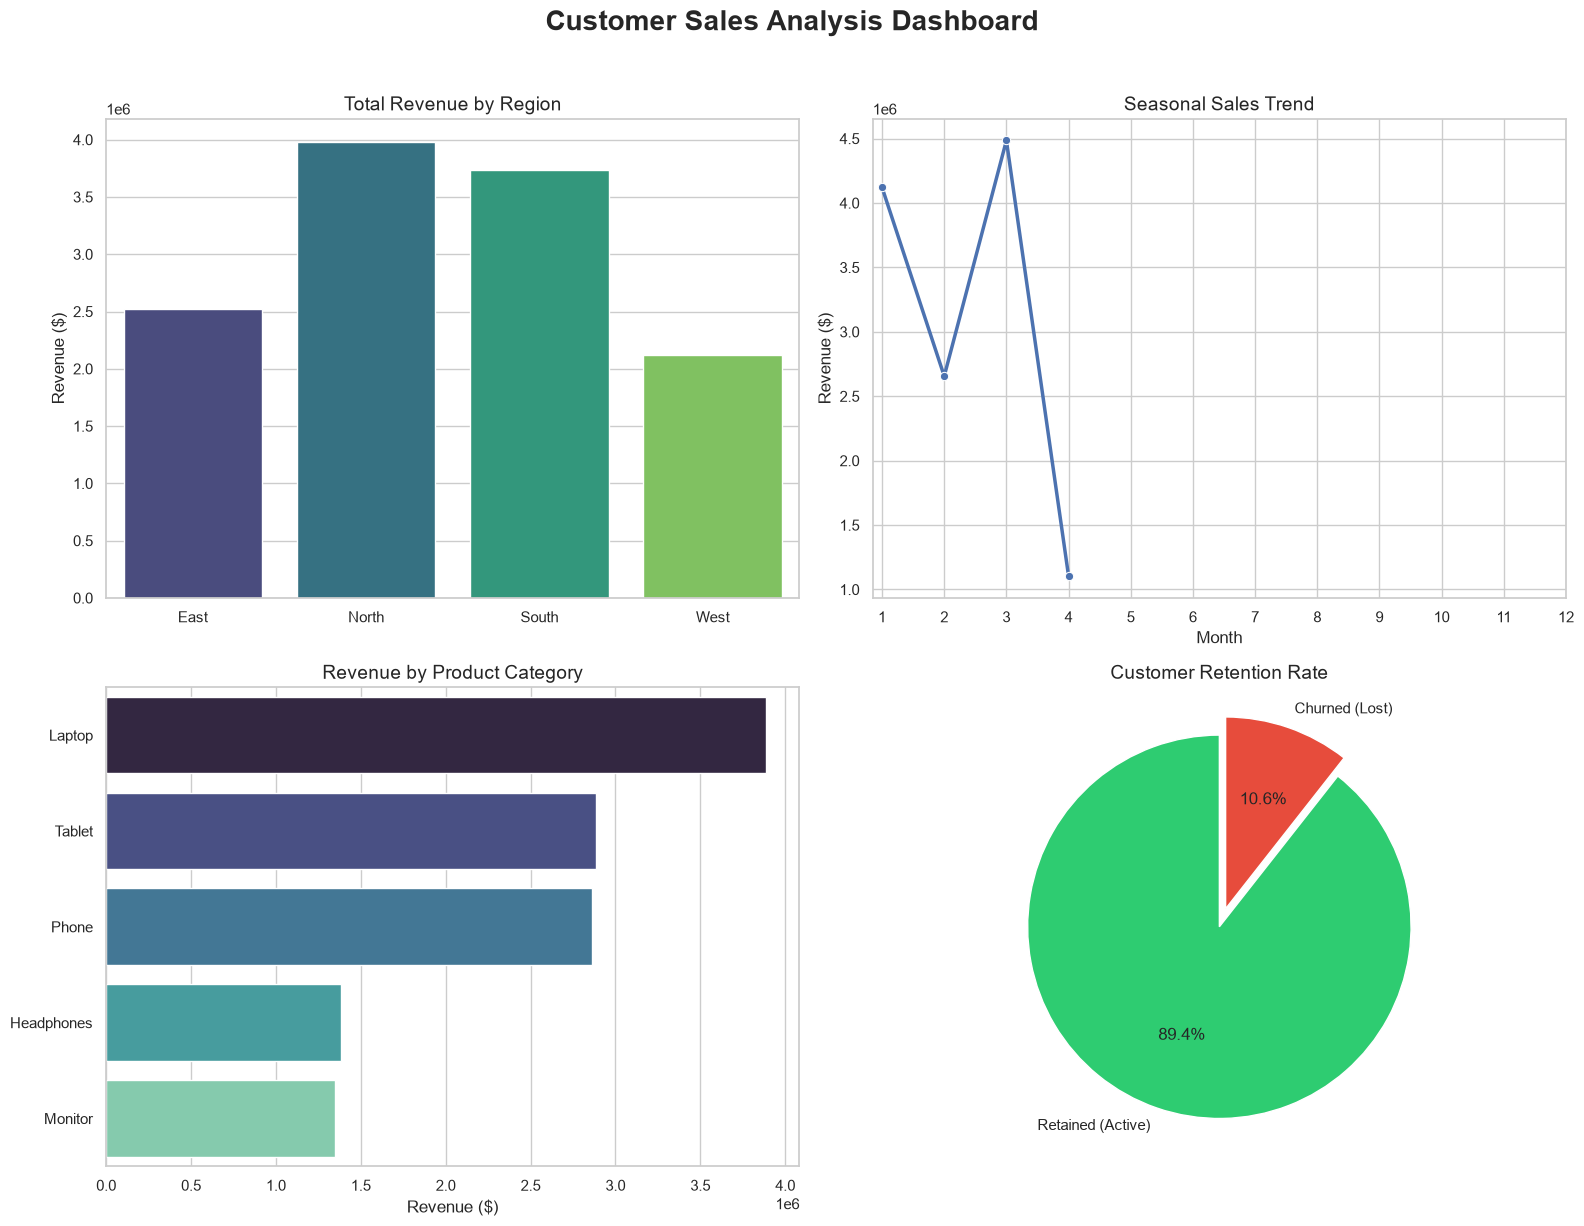

In [ ]:
# Day 6: Dashboard Creation
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a 2x2 grid for our 4 key visualizations
fig, axes = plt.subplots(2, 2)
fig.suptitle('Customer Sales Analysis Dashboard', fontsize=20, fontweight='bold', y=1.02)

# --- Chart 1: Regional Sales Distribution (Bar Chart) ---
regional_sales = merged_df.groupby('Region')['Calculated_Total'].sum().reset_index()
sns.barplot(
    data=regional_sales, 
    x='Region', 
    y='Calculated_Total', 
    ax=axes[0, 0], 
    palette='viridis',
    hue='Region',
    legend=False
)
axes[0, 0].set_title('Total Revenue by Region', fontsize=14)
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xlabel('')

# --- Chart 2: Monthly Sales Trends (Line Chart) ---
monthly_sales = merged_df.groupby('Month')['Calculated_Total'].sum().reset_index()
sns.lineplot(
    data=monthly_sales, 
    x='Month', 
    y='Calculated_Total', 
    ax=axes[0, 1], 
    marker='o', 
    color='b', 
    linewidth=2.5
)
axes[0, 1].set_title('Seasonal Sales Trend', fontsize=14)
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_xticks(range(1, 13))

# --- Chart 3: Top Selling Products (Horizontal Bar Chart) ---
product_sales = merged_df.groupby('Product')['Calculated_Total'].sum().reset_index().sort_values('Calculated_Total', ascending=False)
sns.barplot(
    data=product_sales, 
    y='Product', 
    x='Calculated_Total', 
    ax=axes[1, 0], 
    palette='mako',
    hue='Product',
    legend=False
)
axes[1, 0].set_title('Revenue by Product Category', fontsize=14)
axes[1, 0].set_xlabel('Revenue ($)')
axes[1, 0].set_ylabel('')

# --- Chart 4: Customer Retention Status (Pie Chart) ---
churn_counts = customer_df['Churn'].value_counts()
labels = ['Retained (Active)', 'Churned (Lost)']
axes[1, 1].pie(
    churn_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#2ecc71', '#e74c3c'],
    explode=(0, 0.1) # Highlight the churned slice slightly
)
axes[1, 1].set_title('Customer Retention Rate', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [19]:
# Final Output: Analysis Questions Answers

# Q1: Most valuable customers
print("\n1. Who are our most valuable customers?")
print(top_customers[['Customer_ID', 'Calculated_Total']].head(3).to_string(index=False))

# Q2: Products selling together
print("\n2. What products sell best together?")
print("Based on market basket analysis, each customer in this dataset snapshot only has one distinct transaction.")
print("Therefore, no products are currently bought simultaneously. We need recurring transaction data to map cross-selling.")

# Q3: Regional Sales
print("\n3. Which regions have the highest sales?")
print(regional_distribution.to_string(index=False))

# Q4: Seasonal Trends
print("\n4. What are the seasonal trends?")
print("Sales show high volatility. There is a dip in Month 2, followed by a massive peak in Month 3.")
print(monthly_sales.to_string(index=False))

# Q5: Customer Retention
print("\n5. How can we improve customer retention?")
print(f"Current Retention Rate is {retention_rate:.1f}%.")
print("Recommendation: Implement automated exit surveys for the ~10.6% of churning customers to identify pain points, and offer targeted discounts before contracts expire.")


1. Who are our most valuable customers?
Customer_ID  Calculated_Total
    CUST016            373932
    CUST007            363870
    CUST083            350888

2. What products sell best together?
Based on market basket analysis, each customer in this dataset snapshot only has one distinct transaction.
Therefore, no products are currently bought simultaneously. We need recurring transaction data to map cross-selling.

3. Which regions have the highest sales?
Region  Calculated_Total
 North           3983635
 South           3737852
  East           2519639
  West           2123922

4. What are the seasonal trends?
Sales show high volatility. There is a dip in Month 2, followed by a massive peak in Month 3.
 Month  Calculated_Total
     1           4120524
     2           2656050
     3           4485006
     4           1103468

5. How can we improve customer retention?
Current Retention Rate is 89.4%.
Recommendation: Implement automated exit surveys for the ~10.6% of churning custo